In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
# warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
# warnings.filterwarnings("ignore", message=".*LightGBM.*")

In [2]:
# Load data + constants
DATA_PATH = "career_dataset_final.csv"
LABEL_COL = "job_role"
DOMAIN_COL = "career_domain"
SEED = 42

df = pd.read_csv(DATA_PATH)

# Output folder for saved files
OUT_DIR = Path("artifacts_layer")
OUT_DIR.mkdir(exist_ok=True)
print("Dataset shape:", df.shape)
print("Total columns:", len(df.columns))

Dataset shape: (30000, 88)
Total columns: 88


In [3]:
if "career_domain" not in df.columns:
    raise ValueError("career_domain column not found in df. Can't build role_to_domain mapping.")

role_to_domain = (
    df[[LABEL_COL, DOMAIN_COL]]
    .dropna()
    .drop_duplicates()
    .groupby(LABEL_COL)[DOMAIN_COL]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

(OUT_DIR / "role_to_domain.json").write_text(json.dumps(role_to_domain, indent=2))
print("Saved role_to_domain.json")
print("Mapping size:", len(role_to_domain))

Saved role_to_domain.json
Mapping size: 40


In [4]:
# LAYER 1: Data Preparation & EDA

In [5]:
df.head()

,career_domain,math_scores,cs_fundamentals_scores,cgpa,cognitive_ability_score,programming_skill,web_dev_skill,mobile_dev_skill,data_analytics_skill,data_science_ml_skill,...,siem_experience_score,incident_response_cases,vuln_assessments_done,pentest_tools_known_count,compliance_frameworks_known_count,embedded_c_cpp_skill,microcontroller_projects_count,rtos_experience_score,firmware_debugging_skill,job_role
0,"Cloud, DevOps & Platform Engineering",71.42,80.80,8.16,5.81,5.82,5.77,4.27,5.59,2.96,...,2.14,0,0,0,0,2.54,0,2.59,2.44,Platform Engineer
1,Software Engineering,48.74,75.35,9.14,6.82,3.33,3.38,5.62,6.73,4.71,...,2.16,0,0,0,0,3.29,0,2.36,2.81,Application Support Engineer
2,Cybersecurity,75.15,75.85,8.48,3.73,5.90,4.69,1.68,2.89,4.38,...,5.24,2,3,0,5,0.61,0,1.91,5.83,GRC Analyst
3,Cybersecurity,58.15,73.91,8.72,6.28,6.53,2.29,1.57,6.86,2.48,...,7.83,13,12,6,0,1.92,0,3.40,3.08,Cybersecurity Engineer
4,Data & Artificial Intelligence,89.58,95.37,9.31,7.66,5.75,2.21,1.46,9.80,3.70,...,4.35,1,1,0,0,2.60,0,2.43,2.90,Data Analyst


In [6]:
df.dtypes

career_domain                         str
math_scores                       float64
cs_fundamentals_scores            float64
cgpa                              float64
cognitive_ability_score           float64
                                   ...   
embedded_c_cpp_skill              float64
microcontroller_projects_count      int64
rtos_experience_score             float64
firmware_debugging_skill          float64
job_role                              str
Length: 88, dtype: object

In [7]:
display(df.dtypes.value_counts().rename("count").to_frame())

,count
int64,50
float64,36
str,2


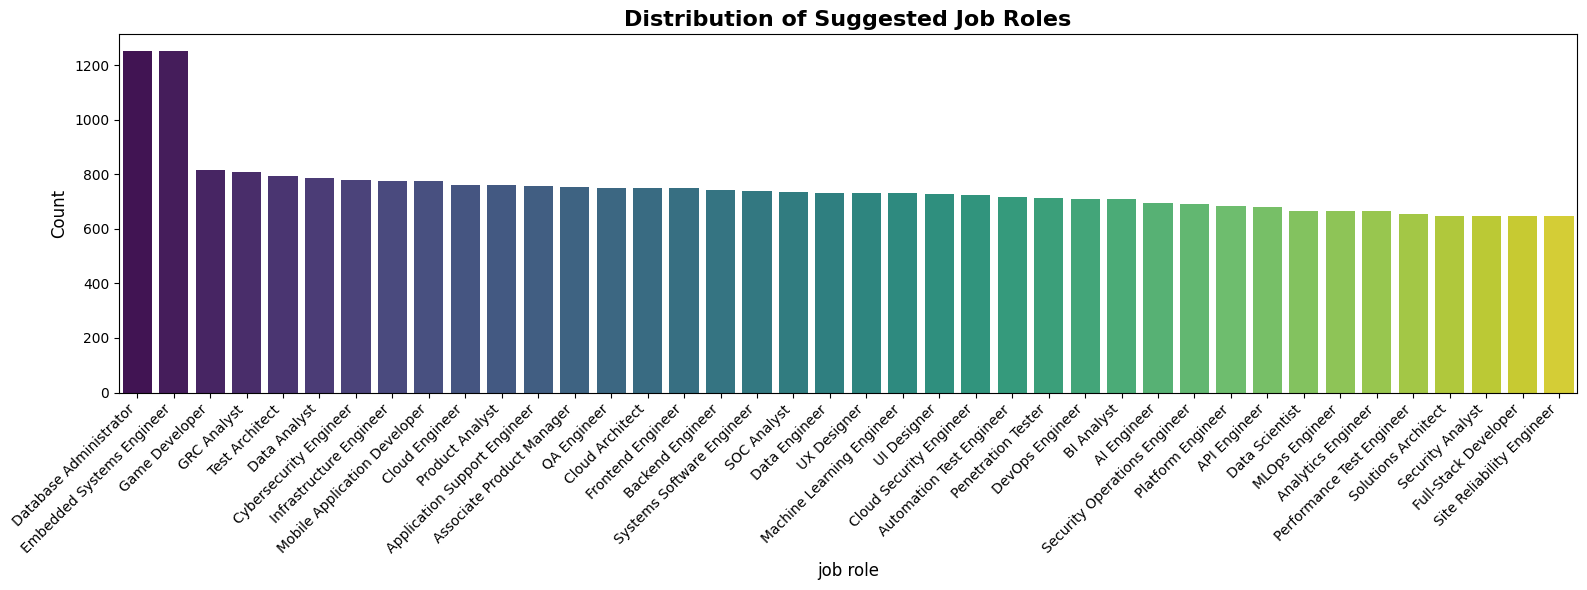

In [8]:
# Job Role Distribution (Full dataset)
plt.figure(figsize=(16, 6))
job_counts = df["job_role"].value_counts()
sns.barplot( x=job_counts.index,y=job_counts.values,hue=job_counts.index,palette="viridis",legend=False)
plt.title("Distribution of Suggested Job Roles", fontsize=16, fontweight="bold")
plt.xlabel("job role", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
df.isnull()

,career_domain,math_scores,cs_fundamentals_scores,cgpa,cognitive_ability_score,programming_skill,web_dev_skill,mobile_dev_skill,data_analytics_skill,data_science_ml_skill,...,siem_experience_score,incident_response_cases,vuln_assessments_done,pentest_tools_known_count,compliance_frameworks_known_count,embedded_c_cpp_skill,microcontroller_projects_count,rtos_experience_score,firmware_debugging_skill,job_role
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# Target columns check
required_cols = [LABEL_COL]
if DOMAIN_COL in df.columns:
    required_cols.append(DOMAIN_COL)

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Required columns present:", required_cols)

Required columns present: ['job_role', 'career_domain']


In [11]:
# Missing values check
missing_total = int(df.isna().sum().sum())
print("Total missing cells:", missing_total)

Total missing cells: 0


In [12]:
# Duplicate rows
dup_rate = float(df.duplicated().mean())
print("Duplicate row rate:", round(dup_rate, 6))

Duplicate row rate: 0.0


In [13]:
# Constant columns (only 1 unique value)
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
print("Constant columns count:", len(constant_cols))
if constant_cols:
    print("Sample constant columns:", constant_cols[:40])

Constant columns count: 0


In [14]:
# Leakage audit (simple checks)
def tokenize(text: str):
    return re.findall(r"[A-Za-z0-9_+\-]+", str(text).lower())

# Build label token set (words from job roles)
label_values = df[LABEL_COL].astype(str).unique().tolist()
label_tokens = set()
for lv in label_values:
    for t in tokenize(lv):
        if len(t) >= 4:
            label_tokens.add(t)

print("Label token count:", len(label_tokens))

# Suspicious column names (contains label tokens)
suspicious_cols = []
for c in df.columns:
    if c in [LABEL_COL, DOMAIN_COL]:
        continue
    name_tokens = set(tokenize(c))
    if len(name_tokens & label_tokens) > 0:
        suspicious_cols.append(c)

print("\nSuspicious columns by name (possible leakage):", suspicious_cols[:30])

# Text-like columns check (if any)
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
text_like_cols = []
for c in obj_cols:
    if c in [LABEL_COL, DOMAIN_COL]:
        continue
    avg_len = df[c].fillna("").astype(str).map(len).mean()
    if avg_len >= 25:
        text_like_cols.append(c)

print("\nText-like columns:", text_like_cols)

# Save leakage report
leakage_report = {
    "label_tokens_count": int(len(label_tokens)),
    "suspicious_feature_names": suspicious_cols,
    "text_like_columns": text_like_cols,
}
(OUT_DIR / "leakage_report.json").write_text(json.dumps(leakage_report, indent=2))
print("\nSaved leakage_report.json")

Label token count: 41

Suspicious columns by name (possible leakage): []

Text-like columns: []

Saved leakage_report.json


In [15]:
# Target balance summary
role_counts = df[LABEL_COL].astype(str).value_counts()
imbalance_ratio = role_counts.max() / role_counts.min()

print("Number of roles:", role_counts.shape[0])
print("Min count:", int(role_counts.min()))
print("Max count:", int(role_counts.max()))
print("Imbalance ratio (max/min):", round(float(imbalance_ratio), 4))

display(
    pd.DataFrame({
        "count": role_counts.head(40),
        "percent": (role_counts.head(40) / len(df) * 100).round(2)
    })
)

Number of roles: 40
Min count: 646
Max count: 1250
Imbalance ratio (max/min): 1.935


,count,percent
job_role,,
Database Administrator,1250,4.17
Embedded Systems Engineer,1250,4.17
Game Developer,814,2.71
GRC Analyst,808,2.69
Test Architect,793,2.64
Data Analyst,785,2.62
Cybersecurity Engineer,777,2.59
Infrastructure Engineer,776,2.59
Mobile Application Developer,774,2.58


In [16]:
# Layer-2: Train / Val / Test Split (Stratified)

In [17]:
# Build X/y safely
y = df[LABEL_COL].astype(str)
drop_cols = [LABEL_COL]
if DOMAIN_COL in df.columns:
    drop_cols.append(DOMAIN_COL) 

X = df.drop(columns=drop_cols, errors="ignore").copy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Dropped:", drop_cols)

X shape: (30000, 86)
y shape: (30000,)
Dropped: ['job_role', 'career_domain']


In [18]:
# Train/Val/Test Split (stratified)
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

val_relative = 0.10 / (1.0 - 0.20) 
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    random_state=SEED,
    stratify=y_trainval
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", y_train.nunique(), y_val.nunique(), y_test.nunique())

# Save split sizes
split_meta = {
    "seed": SEED,
    "sizes": {"train": len(X_train), "val": len(X_val), "test": len(X_test)},
    "dropped_cols": drop_cols
}
(OUT_DIR / "split_meta.json").write_text(json.dumps(split_meta, indent=2))
print("Saved split_meta.json")

Train: (21000, 86) Val: (3000, 86) Test: (6000, 86)
Classes: 40 40 40
Saved split_meta.json


In [19]:
# LAYER 3: Feature Engineering & Selection

In [20]:
# Simple feature engineering (safe rules)
def add_simple_engineered_features(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()

    # Activity total (only if columns exist)
    activity_cols = [c for c in ["project_count", "github_commits_90d", "hackathons_participated"] if c in X_out.columns]
    if len(activity_cols) >= 2:
        X_out["activity_total"] = X_out[activity_cols].sum(axis=1)

    # Security total (only if columns exist)
    sec_cols = [c for c in ["pentest_tools_known_count", "vuln_assessments_done", "ctf_participation"] if c in X_out.columns]
    if len(sec_cols) >= 2:
        X_out["security_total"] = X_out[sec_cols].sum(axis=1)

    # Skill rating stats (if you have many *_rating columns)
    rating_cols = [c for c in X_out.columns if c.endswith("_rating")]
    if len(rating_cols) >= 5:
        X_out["skill_rating_mean"] = X_out[rating_cols].mean(axis=1)
        X_out["skill_rating_std"] = X_out[rating_cols].std(axis=1)

    return X_out


X_train_fe = add_simple_engineered_features(X_train)
X_val_fe   = add_simple_engineered_features(X_val)
X_test_fe  = add_simple_engineered_features(X_test)

print("Before FE:", X_train.shape, "After FE:", X_train_fe.shape)

Before FE: (21000, 86) After FE: (21000, 88)


In [21]:
# Correlation-based feature selection (train only)
def find_high_corr_drops(X_train_df: pd.DataFrame, threshold: float = 0.85) -> list:
    numeric_cols = [c for c in X_train_df.columns if pd.api.types.is_numeric_dtype(X_train_df[c])]
    X_num = X_train_df[numeric_cols].copy()

    if X_num.shape[1] < 2:
        return []

    corr = X_num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]
    return to_drop


corr_threshold = 0.85
drop_corr_cols = find_high_corr_drops(X_train_fe, threshold=corr_threshold)

print("Correlated drop count:", len(drop_corr_cols))
print("Sample drop cols:", drop_corr_cols[:20])

# Apply same drop list to val/test
X_train_sel = X_train_fe.drop(columns=drop_corr_cols, errors="ignore")
X_val_sel   = X_val_fe.drop(columns=drop_corr_cols, errors="ignore")
X_test_sel  = X_test_fe.drop(columns=drop_corr_cols, errors="ignore")

print("After selection shapes:", X_train_sel.shape, X_val_sel.shape, X_test_sel.shape)

# Save selection artifacts
(OUT_DIR / "dropped_correlated_features.json").write_text(
    json.dumps({"threshold": corr_threshold, "dropped_features": drop_corr_cols}, indent=2)
)
(OUT_DIR / "selected_features.json").write_text(
    json.dumps({"selected_features": X_train_sel.columns.tolist()}, indent=2)
)

print("Saved dropped_correlated_features.json and selected_features.json")

Correlated drop count: 2
Sample drop cols: ['activity_total', 'security_total']
After selection shapes: (21000, 86) (3000, 86) (6000, 86)
Saved dropped_correlated_features.json and selected_features.json


Numeric columns: 88

Top 20 correlated feature pairs [TRAIN]:


,,abs_corr
activity_total,github_commits_90d,0.999671
github_commits_90d,activity_total,0.999671
security_total,vuln_assessments_done,0.971634
vuln_assessments_done,security_total,0.971634
pentest_tools_known_count,security_total,0.907304
security_total,pentest_tools_known_count,0.907304
vuln_assessments_done,pentest_tools_known_count,0.782129
pentest_tools_known_count,vuln_assessments_done,0.782129
activity_total,project_count,0.768186
project_count,activity_total,0.768186


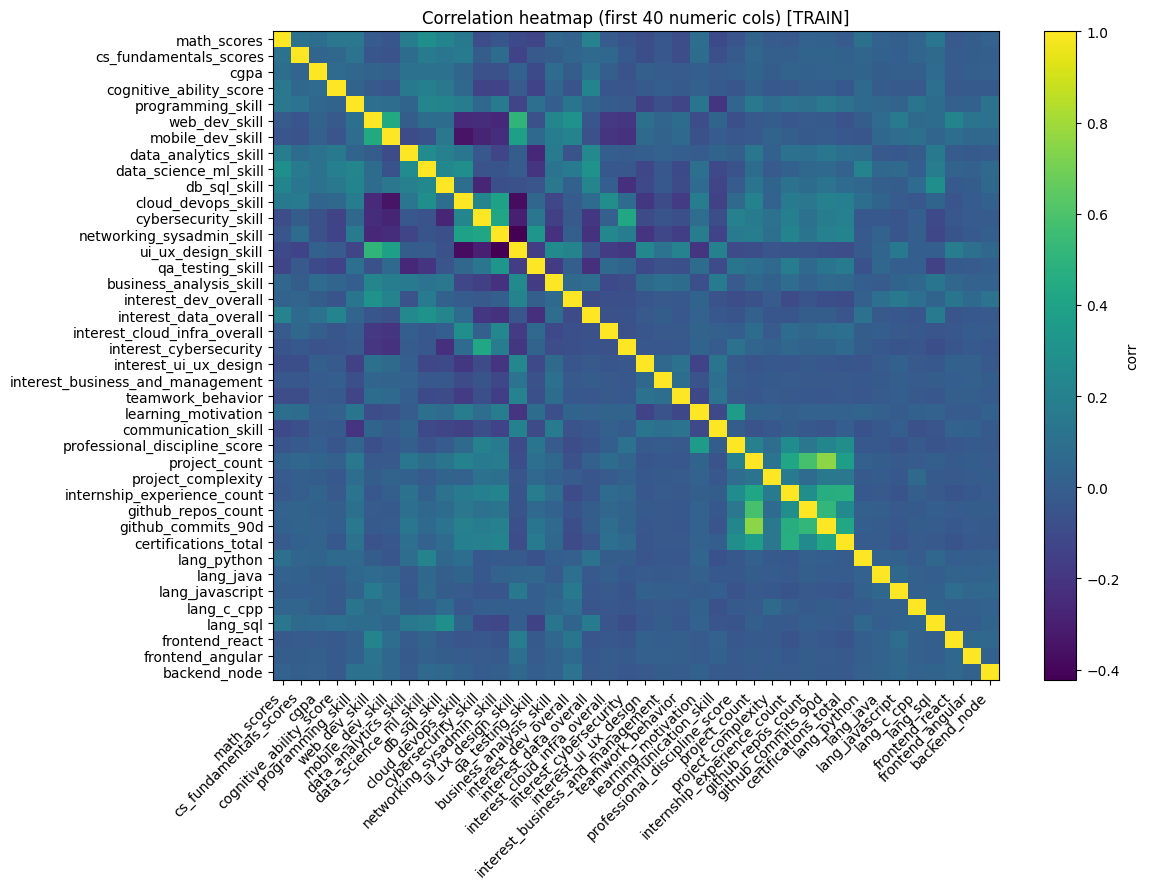

In [22]:
# Correlation report (train only)
num_cols = [c for c in X_train_fe.columns if pd.api.types.is_numeric_dtype(X_train_fe[c])]
print("Numeric columns:", len(num_cols))

if len(num_cols) >= 2:
    # correlation matrix
    corr = X_train_fe[num_cols].corr().abs()
    # Make a writable numpy copy, then zero diagonal
    corr_arr = corr.to_numpy(copy=True)
    np.fill_diagonal(corr_arr, 0)
    # put back into a DataFrame (same labels)
    corr = pd.DataFrame(corr_arr, index=corr.index, columns=corr.columns)
    # top correlated pairs
    pairs = corr.unstack().sort_values(ascending=False)
    pairs = pairs[pairs > 0].head(20)
    print("\nTop 20 correlated feature pairs [TRAIN]:")
    display(pairs.to_frame("abs_corr"))

    # Heatmap (limit for readability)
    N = min(40, len(num_cols))
    small_cols = num_cols[:N]
    corr_small = X_train_fe[small_cols].corr()
    plt.figure(figsize=(12, 9))
    plt.imshow(corr_small.values, aspect="auto")
    plt.colorbar(label="corr")
    plt.xticks(range(len(small_cols)), small_cols, rotation=45, ha="right")
    plt.yticks(range(len(small_cols)), small_cols)
    plt.title(f"Correlation heatmap (first {N} numeric cols) [TRAIN]")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation.")

In [23]:
# Layer 4: Preprocessing (Fit on TRAIN only) + Safety Checks

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import joblib

# Detect numeric vs categorical columns
numeric_cols = [c for c in X_train_sel.columns if pd.api.types.is_numeric_dtype(X_train_sel[c])]
categorical_cols = [c for c in X_train_sel.columns if c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Example numeric:", numeric_cols[:10])
print("Example categorical:", categorical_cols[:10])


Numeric columns: 86
Categorical columns: 0
Example numeric: ['math_scores', 'cs_fundamentals_scores', 'cgpa', 'cognitive_ability_score', 'programming_skill', 'web_dev_skill', 'mobile_dev_skill', 'data_analytics_skill', 'data_science_ml_skill', 'db_sql_skill']
Example categorical: []


In [25]:
# Numeric preprocessing
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine them
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop"
)
print("Preprocessor ready.")
preprocess

Preprocessor ready.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [26]:
# Fit on TRAIN only + transform VAL/TEST
X_train_proc = preprocess.fit_transform(X_train_sel)
X_val_proc = preprocess.transform(X_val_sel)
X_test_proc = preprocess.transform(X_test_sel)

print("Processed shapes:")
print("Train:", X_train_proc.shape)
print("Val  :", X_val_proc.shape)
print("Test :", X_test_proc.shape)

Processed shapes:
Train: (21000, 86)
Val  : (3000, 86)
Test : (6000, 86)


In [27]:
# Safety checks (shapes, NaN/Inf)
def check_same_columns():
    a = list(X_train_sel.columns)
    b = list(X_val_sel.columns)
    c = list(X_test_sel.columns)
    print("Train vs Val columns identical:", a == b)
    print("Train vs Test columns identical:", a == c)

check_same_columns()

def check_matrix_ok(mat, name):
    arr = mat.toarray() if hasattr(mat, "toarray") else np.asarray(mat)
    print(name, "NaNs:", int(np.isnan(arr).sum()), "| Infs:", int(np.isinf(arr).sum()))

check_matrix_ok(X_train_proc, "X_train_proc")
check_matrix_ok(X_val_proc, "X_val_proc")
check_matrix_ok(X_test_proc, "X_test_proc")

Train vs Val columns identical: True
Train vs Test columns identical: True
X_train_proc NaNs: 0 | Infs: 0
X_val_proc NaNs: 0 | Infs: 0
X_test_proc NaNs: 0 | Infs: 0


In [28]:
# Label encoding (consistent) + saving
label_encoder = LabelEncoder()

# Fit on TRAIN only
y_train_enc = label_encoder.fit_transform(y_train.astype(str))
y_val_enc = label_encoder.transform(y_val.astype(str))
y_test_enc = label_encoder.transform(y_test.astype(str))

print("Number of classes:", len(label_encoder.classes_))
# Save encoder
joblib.dump(label_encoder, OUT_DIR / "label_encoder.joblib")
print("Saved label_encoder.joblib")

Number of classes: 40
Saved label_encoder.joblib


In [29]:
#  Save artifacts for reproducibility
joblib.dump(preprocess, OUT_DIR / "preprocess.joblib")

final_feature_list = X_train_sel.columns.tolist()
(OUT_DIR / "final_feature_list.json").write_text(
    json.dumps({"final_feature_list": final_feature_list}, indent=2)
)
print("Saved final_feature_list.json")

# Save feature engineering metadata (what was created)
engineered_features = sorted(list(set(X_train_fe.columns) - set(X_train.columns)))

fe_meta = {
    "engineered_features": engineered_features,
    "notes": "Engineered features are created only if required base columns exist.",
}
(OUT_DIR / "feature_engineering_meta.json").write_text(json.dumps(fe_meta, indent=2))
print("Saved feature_engineering_meta.json")

# Save preprocessing output feature names (useful for debugging later)
try:
    feature_names_out = preprocess.get_feature_names_out().tolist()
except Exception:
    feature_names_out = None

(OUT_DIR / "preprocess_feature_names.json").write_text(
    json.dumps({"feature_names_out": feature_names_out}, indent=2)
)
print("Saved preprocess_feature_names.json")

Saved final_feature_list.json
Saved feature_engineering_meta.json
Saved preprocess_feature_names.json


In [30]:
# LAYER 5: Model Selection & Training

In [31]:
import json
import joblib
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
    top_k_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb

In [32]:
# Helper function to train + evaluate on VAL
def eval_on_val_metrics(model, X_tr, y_tr, X_v, y_v, k=3):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_v)
    metrics = {
        "accuracy": float(accuracy_score(y_v, pred)),
        "macro_f1": float(f1_score(y_v, pred, average="macro")),
        "macro_precision": float(precision_score(y_v, pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_v, pred, average="macro", zero_division=0)),
        "top3_acc": None,
        "top3_f1": None,
        "log_loss": None,
    }

    # Top-3 + log_loss need probabilities
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_v)
        metrics["log_loss"] = float(
            log_loss(y_v, proba, labels=np.arange(len(label_encoder.classes_)))
        )
        # Top-3 accuracy
        metrics["top3_acc"] = float(
            top_k_accuracy_score(
                y_v,
                proba,
                k=k,
                labels=np.arange(len(label_encoder.classes_)),
            )
        )
        topk_idx = np.argsort(proba, axis=1)[:, -k:]  
        correct_in_topk = np.array([y_v[i] in topk_idx[i] for i in range(len(y_v))], dtype=int)
        metrics["top3_f1"] = float(f1_score(np.ones_like(correct_in_topk), correct_in_topk, average="binary"))

    return metrics, model


def print_metrics_list(title: str, metrics: dict):
    order = ["accuracy", "macro_f1", "macro_precision", "macro_recall", "top3_acc", "top3_f1", "log_loss"]
    print(f"\n{title}")
    for key in order:
        val = metrics.get(key, None)
        if val is None:
            print(f"{key}: None")
        else:
            print(f"{key}: {val:.6f}")

def top3_f1_from_proba(y_true: np.ndarray, proba: np.ndarray, k: int = 3) -> float:
    topk_idx = np.argsort(proba, axis=1)[:, -k:]
    correct_in_topk = np.array([y_true[i] in topk_idx[i] for i in range(len(y_true))], dtype=int)
    return float(f1_score(np.ones_like(correct_in_topk), correct_in_topk, average="binary"))

In [33]:
# SVM (RBF) model + results
svm_model = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=SEED,
)

svm_metrics, svm_fitted = eval_on_val_metrics(
    svm_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
print_metrics_list("SVM results", svm_metrics)


SVM results
accuracy: 0.764000
macro_f1: 0.752448
macro_precision: 0.753269
macro_recall: 0.752631
top3_acc: 0.970000
top3_f1: 0.984772
log_loss: 0.637804


In [34]:
# Random Forest model + results
rf_model = RandomForestClassifier(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=5,
    bootstrap=True,
    n_jobs=-1,
    random_state=SEED,
)

rf_metrics, rf_fitted = eval_on_val_metrics(
    rf_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
print_metrics_list("RandomForest results", rf_metrics)


RandomForest results
accuracy: 0.771667
macro_f1: 0.756221
macro_precision: 0.762293
macro_recall: 0.758604
top3_acc: 0.955000
top3_f1: 0.976982
log_loss: 1.113459


In [35]:
# Logistic Regression model + results
lr_model = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    penalty="l2",
    class_weight="balanced",
    max_iter=4000,
)

lr_metrics, lr_fitted = eval_on_val_metrics(
    lr_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)
print_metrics_list("LogisticRegression results", lr_metrics)


LogisticRegression results
accuracy: 0.767333
macro_f1: 0.756209
macro_precision: 0.756916
macro_recall: 0.757115
top3_acc: 0.966667
top3_f1: 0.983051
log_loss: 0.633025


In [36]:
# XGBoost model + results
xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
)

xgb_metrics, xgb_fitted = eval_on_val_metrics(
    xgb_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)

print_metrics_list("XGBoost results", xgb_metrics)


XGBoost results
accuracy: 0.777000
macro_f1: 0.764664
macro_precision: 0.766112
macro_recall: 0.765606
top3_acc: 0.968667
top3_f1: 0.984084
log_loss: 0.660672


In [37]:
# LightGBM model + results
lgbm_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=-1,
)

lgbm_metrics, lgbm_fitted = eval_on_val_metrics(
    lgbm_model, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)

print_metrics_list("LightGBM results", lgbm_metrics)


LightGBM results
accuracy: 0.773333
macro_f1: 0.760583
macro_precision: 0.762157
macro_recall: 0.761754
top3_acc: 0.966667
top3_f1: 0.983051
log_loss: 0.758396


In [38]:
# Compare models
results = [
    {"model": "svm_rbf", **svm_metrics},
    {"model": "random_forest", **rf_metrics},
    {"model": "logistic_regression", **lr_metrics},
    {"model": "xgboost", **xgb_metrics},
    {"model": "lightgbm", **lgbm_metrics},
]

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
preferred_cols = [
    "model",
    "accuracy",
    "macro_f1",
    "macro_precision",
    "macro_recall",
    "top3_acc",
    "top3_f1",
    "log_loss",
]
results_df = results_df[[c for c in preferred_cols if c in results_df.columns]]

display(results_df)
# display(results_df.sort_values("top3_acc", ascending=False))

,model,accuracy,macro_f1,macro_precision,macro_recall,top3_acc,top3_f1,log_loss
3,xgboost,0.777000,0.764664,0.766112,0.765606,0.968667,0.984084,0.660672
4,lightgbm,0.773333,0.760583,0.762157,0.761754,0.966667,0.983051,0.758396
1,random_forest,0.771667,0.756221,0.762293,0.758604,0.955000,0.976982,1.113459
2,logistic_regression,0.767333,0.756209,0.756916,0.757115,0.966667,0.983051,0.633025
0,svm_rbf,0.764000,0.752448,0.753269,0.752631,0.970000,0.984772,0.637804


In [39]:
# Calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# Calibrate Logistic Regression probabilities (better confidence values)
calibrated_lr = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        C=1.0,
        solver="lbfgs",
        penalty="l2",
    ),
    method="sigmoid",
    cv=3
)

cal_lr_metrics, cal_lr_fitted = eval_on_val_metrics(
    calibrated_lr, X_train_proc, y_train_enc, X_val_proc, y_val_enc, k=3
)

print_metrics_list("Calibrated Logistic Regression VAL results", cal_lr_metrics)


Calibrated Logistic Regression VAL results
accuracy: 0.733667
macro_f1: 0.714994
macro_precision: 0.727355
macro_recall: 0.719387
top3_acc: 0.962000
top3_f1: 0.980632
log_loss: 0.957965


In [40]:
# OOF stacking helpers 
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
def aligned_proba(model, X, n_classes):
    proba = model.predict_proba(X)
    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
    aligned[:, model.classes_] = proba
    return aligned

def build_oof_stack_features(base_models, X_tr, y_tr, X_v, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    n_classes = len(np.unique(y_tr))

    meta_train_parts = []
    meta_val_parts = []

    for name, base in base_models.items():
        oof = np.zeros((X_tr.shape[0], n_classes), dtype=float)
        val_accum = np.zeros((X_v.shape[0], n_classes), dtype=float)

        for tr_idx, oof_idx in skf.split(np.zeros(len(y_tr)), y_tr):
            m = clone(base)
            m.fit(X_tr[tr_idx], y_tr[tr_idx])

            oof[oof_idx] = aligned_proba(m, X_tr[oof_idx], n_classes)
            val_accum += aligned_proba(m, X_v, n_classes)

        meta_train_parts.append(oof)
        meta_val_parts.append(val_accum / n_splits)

    return np.hstack(meta_train_parts), np.hstack(meta_val_parts)

print("OOF stacking helpers ready.")

OOF stacking helpers ready.


In [41]:
# Ensemble model: Stacking (XGB + LGBM + LR) 
base_models = {
    "xgb": xgb_model,
    "lgbm": lgbm_model,
    "lr": lr_model,
}
print("Stacking base models:", list(base_models.keys()))

meta_train, meta_val = build_oof_stack_features(
    base_models,
    X_train_proc,
    y_train_enc,
    X_val_proc,
    n_splits=5,
    seed=SEED
)

meta_model = LogisticRegression(C=1.0, solver="lbfgs", penalty="l2", class_weight="balanced", max_iter=4000)
meta_model.fit(meta_train, y_train_enc)
val_pred = meta_model.predict(meta_val)
val_proba = meta_model.predict_proba(meta_val)
n_classes = len(label_encoder.classes_)

stack_metrics = {
    "accuracy": float(accuracy_score(y_val_enc, val_pred)),
    "macro_f1": float(f1_score(y_val_enc, val_pred, average="macro")),
    "macro_precision": float(precision_score(y_val_enc, val_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_val_enc, val_pred, average="macro", zero_division=0)),
    "top3_acc": float(top_k_accuracy_score(y_val_enc, val_proba, k=3, labels=np.arange(n_classes))),
    "top3_f1": float(top3_f1_from_proba(y_val_enc, val_proba, k=3)),
    "log_loss": float(log_loss(y_val_enc, val_proba, labels=np.arange(n_classes))),
}

print_metrics_list("STACKING META MODEL (VAL) results", stack_metrics)

# Meta model classification report table (VAL)
report_dict = classification_report(
    y_val_enc,
    val_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

# Save report files
report_txt = classification_report(
    y_val_enc,
    val_pred,
    target_names=label_encoder.classes_,
    zero_division=0
)
(OUT_DIR / "stacking_meta_classification_report_val.txt").write_text(report_txt)
report_df.to_csv(OUT_DIR / "stacking_meta_classification_report_val.csv", index=True)

# Save ensemble bundle + meta metrics
bundle = {"base_models": base_models, "meta_model": meta_model}
joblib.dump(bundle, OUT_DIR / "stacking_ensemble.joblib")
(OUT_DIR / "stacking_val_results.json").write_text(json.dumps(stack_metrics, indent=2))

print("Saved stacking_ensemble.joblib")
print("Saved stacking_val_results.json")
print("Saved stacking_meta_classification_report_val.txt / .csv")

Stacking base models: ['xgb', 'lgbm', 'lr']

STACKING META MODEL (VAL) results
accuracy: 0.784667
macro_f1: 0.773468
macro_precision: 0.774693
macro_recall: 0.774355
top3_acc: 0.958667
top3_f1: 0.978897
log_loss: 0.641548


,precision,recall,f1-score,support
AI Engineer,0.700000,0.608696,0.651163,69.000000
API Engineer,0.750000,0.794118,0.771429,68.000000
Analytics Engineer,0.600000,0.590909,0.595420,66.000000
Application Support Engineer,0.880000,0.868421,0.874172,76.000000
Associate Product Manager,0.863014,0.840000,0.851351,75.000000
Automation Test Engineer,0.651515,0.597222,0.623188,72.000000
BI Analyst,0.786667,0.830986,0.808219,71.000000
Backend Engineer,0.661972,0.635135,0.648276,74.000000
Cloud Architect,0.772152,0.813333,0.792208,75.000000
Cloud Engineer,0.602941,0.539474,0.569444,76.000000


Saved stacking_ensemble.joblib
Saved stacking_val_results.json
Saved stacking_meta_classification_report_val.txt / .csv


In [42]:
# LAYER 6: Model Evaluation & Testing

In [53]:
ensemble_path = OUT_DIR / "stacking_ensemble.joblib"
ensemble_bundle = joblib.load(ensemble_path)
print("Ensemble loaded:", True, "|", ensemble_path)

Ensemble loaded: True | artifacts_layer\stacking_ensemble.joblib


In [56]:
# Part B: Helper function to evaluate on TEST
def aligned_proba(model, X, n_classes):
    proba = model.predict_proba(X)
    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
    aligned[:, model.classes_] = proba
    return aligned


def predict_proba_ensemble(bundle, X_train, y_train, X_test):
    base_models = bundle["base_models"]
    meta_model = bundle["meta_model"]
    n_classes = len(np.unique(y_train))

    meta_parts = []
    for name, base in base_models.items():
        m = base
        m.fit(X_train, y_train)
        meta_parts.append(aligned_proba(m, X_test, n_classes))

    meta_X = np.hstack(meta_parts)

    proba = meta_model.predict_proba(meta_X)
    pred = meta_model.predict(meta_X)
    return proba, pred


def evaluate_ensemble(bundle, X_train, y_train, X_test, y_test, k=3):
    proba, pred = predict_proba_ensemble(bundle, X_train, y_train, X_test)
    n_classes = len(label_encoder.classes_)
    topk_idx = np.argsort(proba, axis=1)[:, -k:]
    correct_in_topk = np.array([y_test[i] in topk_idx[i] for i in range(len(y_test))], dtype=int)

    metrics = {
        "accuracy": float(accuracy_score(y_test, pred)),
        "macro_f1": float(f1_score(y_test, pred, average="macro")),
        "macro_precision": float(precision_score(y_test, pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_test, pred, average="macro", zero_division=0)),
        "log_loss": float(log_loss(y_test, proba, labels=np.arange(n_classes))),
        "top3_acc": float(top_k_accuracy_score(y_test, proba, k=k, labels=np.arange(n_classes))),
        "top3_f1": float(f1_score(np.ones_like(correct_in_topk), correct_in_topk, average="binary")),
    }

    return metrics, proba, pred

In [55]:
# Evaluate ENSEMBLE on TEST
ens_metrics, ens_proba_test, ens_pred_test = evaluate_ensemble(
    ensemble_bundle, X_train_proc, y_train_enc, X_test_proc, y_test_enc, k=3
)

def print_metrics_list(title: str, metrics: dict):
    order = ["accuracy", "macro_f1", "macro_precision", "macro_recall", "top3_acc", "top3_f1", "log_loss"]
    print(f"\n{title}")
    for k in order:
        v = metrics.get(k, None)
        if v is None:
            print(f"{k}: None")
        else:
            print(f"{k}: {v:.6f}")

print_metrics_list("Ensemble TEST metrics", ens_metrics)

(OUT_DIR / "ensemble_test_metrics.json").write_text(json.dumps(ens_metrics, indent=2))
print("Saved ensemble_test_metrics.json")


Ensemble TEST metrics
accuracy: 0.798000
macro_f1: 0.788636
macro_precision: 0.789523
macro_recall: 0.788661
top3_acc: 0.966000
top3_f1: 0.982706
log_loss: 0.604379
Saved ensemble_test_metrics.json


                              precision    recall  f1-score   support

                 AI Engineer       0.66      0.65      0.66       139
                API Engineer       0.81      0.80      0.81       136
          Analytics Engineer       0.65      0.70      0.67       133
Application Support Engineer       0.84      0.87      0.85       151
   Associate Product Manager       0.90      0.91      0.90       150
    Automation Test Engineer       0.65      0.60      0.62       143
                  BI Analyst       0.87      0.88      0.88       142
            Backend Engineer       0.76      0.78      0.77       148
             Cloud Architect       0.80      0.83      0.82       150
              Cloud Engineer       0.59      0.59      0.59       152
     Cloud Security Engineer       0.88      0.82      0.85       145
      Cybersecurity Engineer       0.74      0.75      0.75       155
                Data Analyst       0.89      0.90      0.90       157
               Data

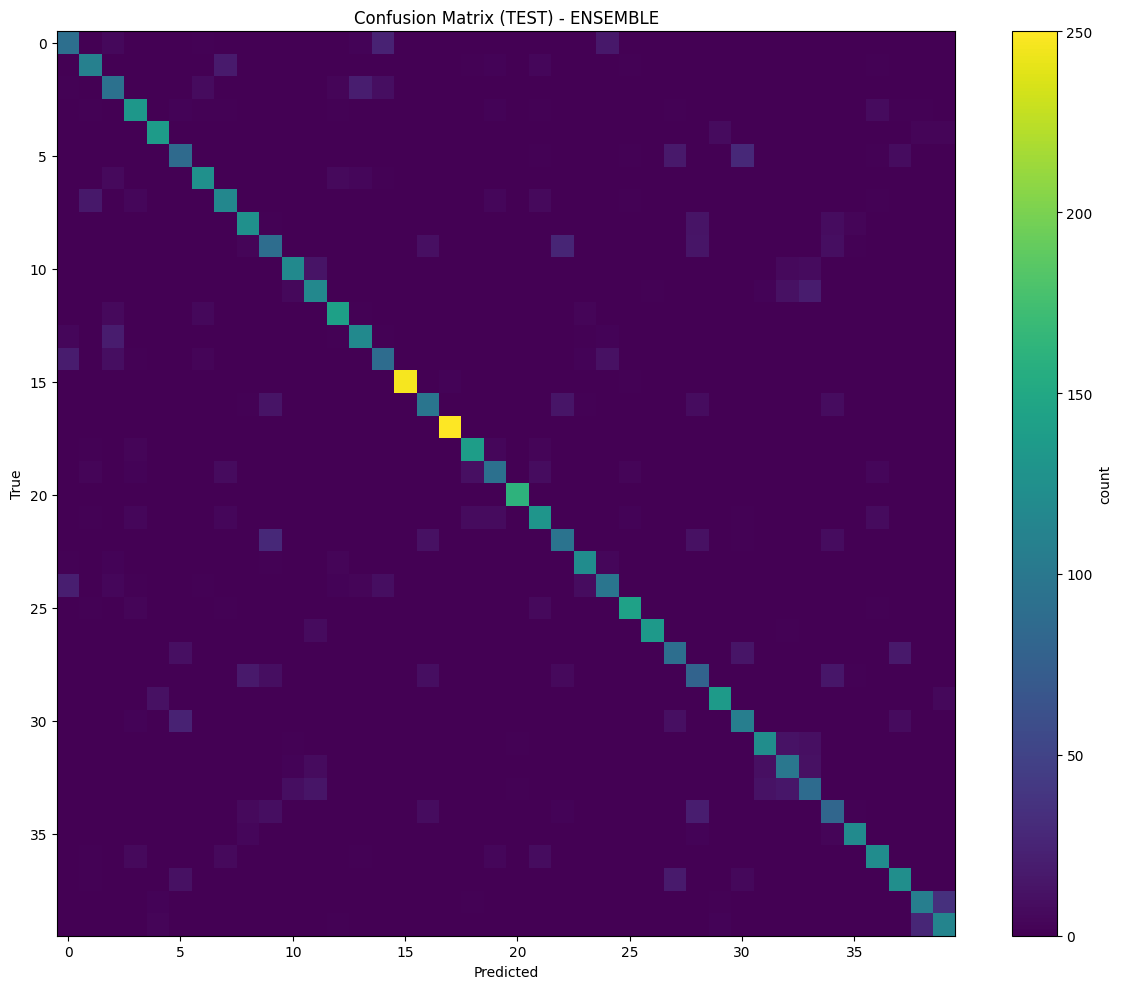

Saved ensemble_classification_report_test.txt
Saved ensemble_confusion_matrix_test.csv and .png


In [57]:
# Reports + Confusion matrices 
# Classification report
report_txt = classification_report(
    y_test_enc, ens_pred_test,
    target_names=label_encoder.classes_,
    zero_division=0
)
print(report_txt)
(OUT_DIR / "ensemble_classification_report_test.txt").write_text(report_txt)

# Confusion matrix
cm = confusion_matrix(y_test_enc, ens_pred_test)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
cm_df.to_csv(OUT_DIR / "ensemble_confusion_matrix_test.csv", index=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm, aspect="auto")
plt.colorbar(label="count")
plt.title("Confusion Matrix (TEST) - ENSEMBLE")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUT_DIR / "ensemble_confusion_matrix_test.png", dpi=200)
plt.show()

print("Saved ensemble_classification_report_test.txt")
print("Saved ensemble_confusion_matrix_test.csv and .png")

In [47]:
# LAYER 7: Output Layer

In [58]:
# Load role->domain mapping (optional)
role_to_domain_path = OUT_DIR / "role_to_domain.json"
role_to_domain = json.loads(role_to_domain_path.read_text()) if role_to_domain_path.exists() else {}

print("role_to_domain loaded:", len(role_to_domain))

role_to_domain loaded: 40


In [75]:
# Part B: Helper: proba -> Top-1/Top-3 recommendations
def topk_from_proba(proba_row, k=3):
    idx = np.argsort(proba_row)[::-1][:k]
    roles = label_encoder.inverse_transform(idx)
    probs = proba_row[idx]
    return [(roles[i], float(probs[i])) for i in range(len(idx))]

def output_df_from_proba(proba, k=3):
    rows = []
    for i in range(proba.shape[0]):
        topk = topk_from_proba(proba[i], k=k)
        topk = [(role, round(prob, 6)) for role, prob in topk]
        top1_role, top1_prob = topk[0]
        rows.append({
            "top1_role": top1_role,
            "top1_prob": round(top1_prob, 6),
            "top1_domain": role_to_domain.get(top1_role, None),
            "top3": topk
        })
    return pd.DataFrame(rows)

In [76]:
# Generate outputs (Top-1 + Top-3) on TEST 
ens_out = output_df_from_proba(ens_proba_test, k=3)
pd.set_option("display.max_colwidth", None)
display(ens_out.head(10))

ens_out.to_csv(OUT_DIR / "topk_outputs_test_ensemble.csv", index=False)
ens_out.to_csv(OUT_DIR / "topk_outputs_test_FINAL.csv", index=False)

print("Saved topk_outputs_test_ensemble.csv")
print("Saved topk_outputs_test_FINAL.csv (same as ensemble)")

,top1_role,top1_prob,top1_domain,top3
0,Machine Learning Engineer,0.803944,Data & Artificial Intelligence,"[(Machine Learning Engineer, 0.803944), (AI Engineer, 0.123334), (Data Scientist, 0.044194)]"
1,Database Administrator,0.993127,Systems & Infrastructure,"[(Database Administrator, 0.993127), (Embedded Systems Engineer, 0.001412), (MLOps Engineer, 0.000451)]"
2,GRC Analyst,0.994648,Cybersecurity,"[(GRC Analyst, 0.994648), (Security Analyst, 0.000356), (Data Analyst, 0.000309)]"
3,Security Operations Engineer,0.856550,Cybersecurity,"[(Security Operations Engineer, 0.85655), (Cybersecurity Engineer, 0.060855), (Cloud Security Engineer, 0.033996)]"
4,Cloud Engineer,0.757081,"Cloud, DevOps & Platform Engineering","[(Cloud Engineer, 0.757081), (Infrastructure Engineer, 0.140731), (DevOps Engineer, 0.04511)]"
5,Database Administrator,0.992785,Systems & Infrastructure,"[(Database Administrator, 0.992785), (Embedded Systems Engineer, 0.001512), (MLOps Engineer, 0.000469)]"
6,Frontend Engineer,0.881291,Software Engineering,"[(Frontend Engineer, 0.881291), (Full-Stack Developer, 0.084922), (Game Developer, 0.014231)]"
7,Mobile Application Developer,0.651362,Software Engineering,"[(Mobile Application Developer, 0.651362), (Database Administrator, 0.071547), (Game Developer, 0.049012)]"
8,Systems Software Engineer,0.965191,Software Engineering,"[(Systems Software Engineer, 0.965191), (Game Developer, 0.00862), (Backend Engineer, 0.008236)]"
9,Application Support Engineer,0.968623,Software Engineering,"[(Application Support Engineer, 0.968623), (Systems Software Engineer, 0.012869), (Game Developer, 0.005796)]"


Saved topk_outputs_test_ensemble.csv
Saved topk_outputs_test_FINAL.csv (same as ensemble)
